In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def erosion(image, kernel_size):
    h, w = image.shape
    result = np.zeros((h, w), dtype=np.uint8)
    k = kernel_size // 2
    for i in range(k, h - k):
        for j in range(k, w - k):
            region = image[i - k:i + k + 1, j - k:j + k + 1]
            if np.all(region == 0):
                result[i, j] = 0
            else:
                result[i, j] = 255
    return result

def dilation(image, kernel_size):
    h, w = image.shape
    result = np.zeros((h, w), dtype=np.uint8)
    k = kernel_size // 2
    for i in range(k, h - k):
        for j in range(k, w - k):
            region = image[i - k:i + k + 1, j - k:j + k + 1]
            if np.any(region == 0):
                result[i, j] = 0
            else:
                result[i, j] = 255
    return result

def opening(image, kernel_size):
    eroded = erosion(image, kernel_size)
    opened = dilation(eroded, kernel_size)
    return opened

def closing(image, kernel_size):
    dilated = dilation(image, kernel_size)
    closed = erosion(dilated, kernel_size)
    return closed

def border(image, kernel_size):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded = cv2.erode(image, kernel, iterations=1)
    boundary = cv2.subtract(image, eroded)
    return boundary


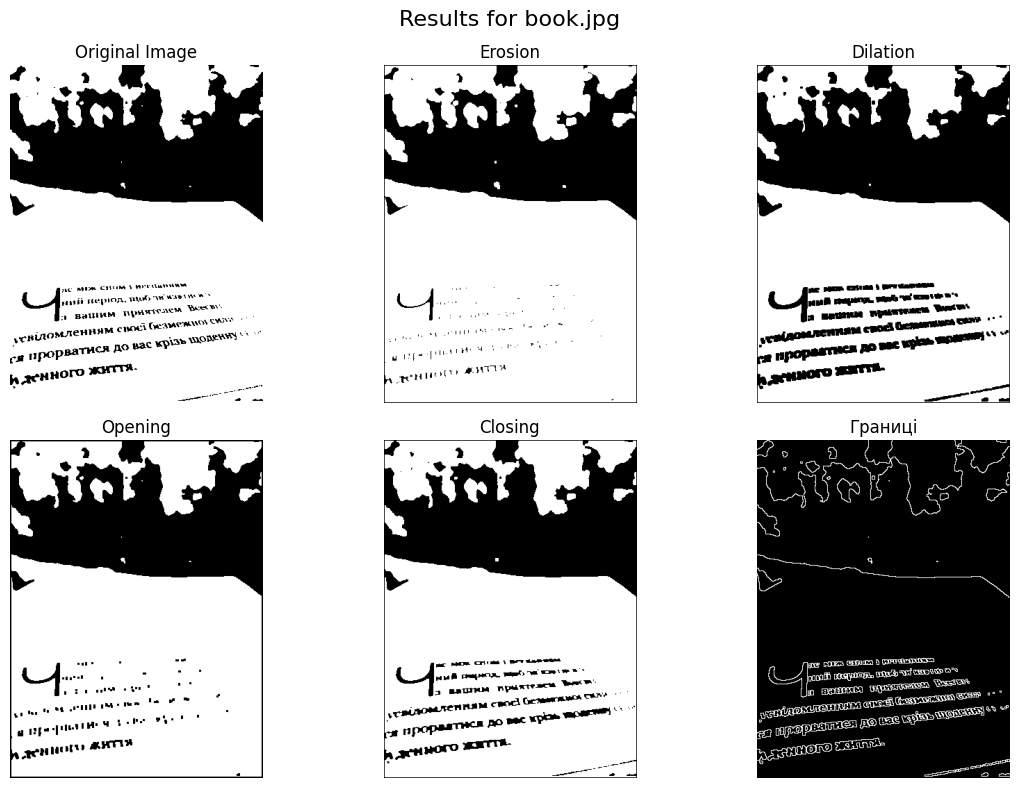

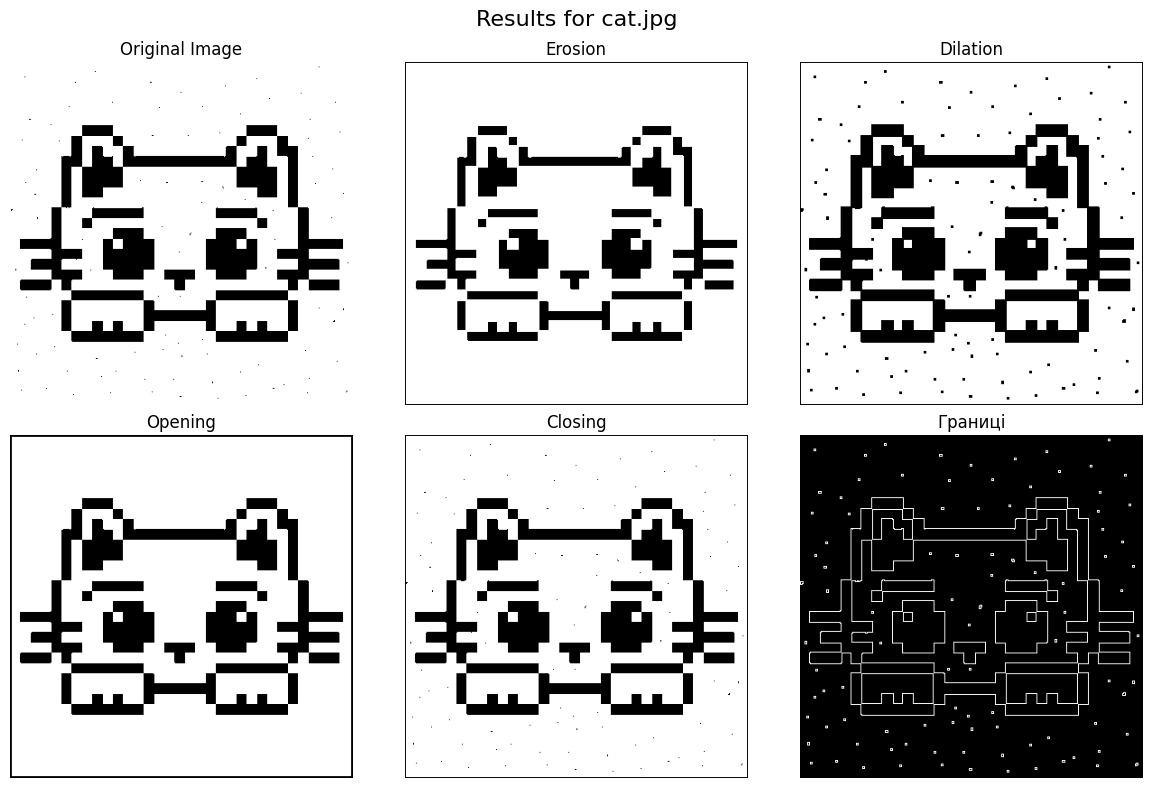

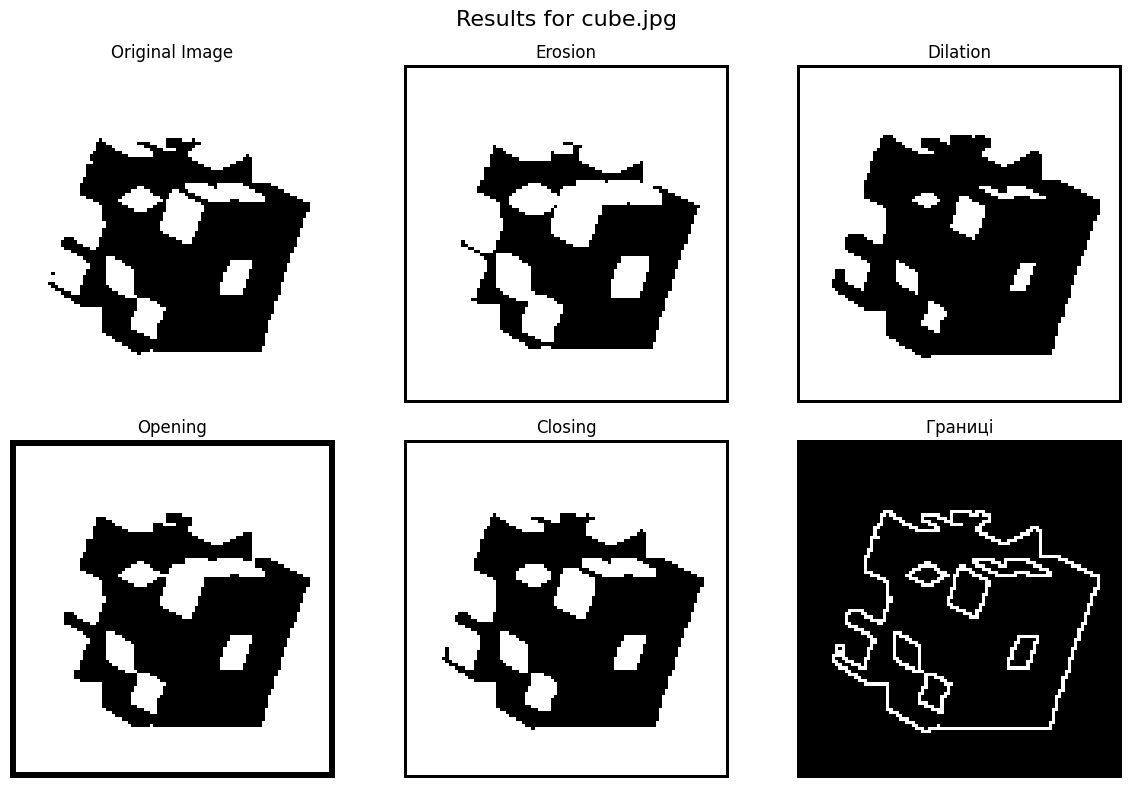

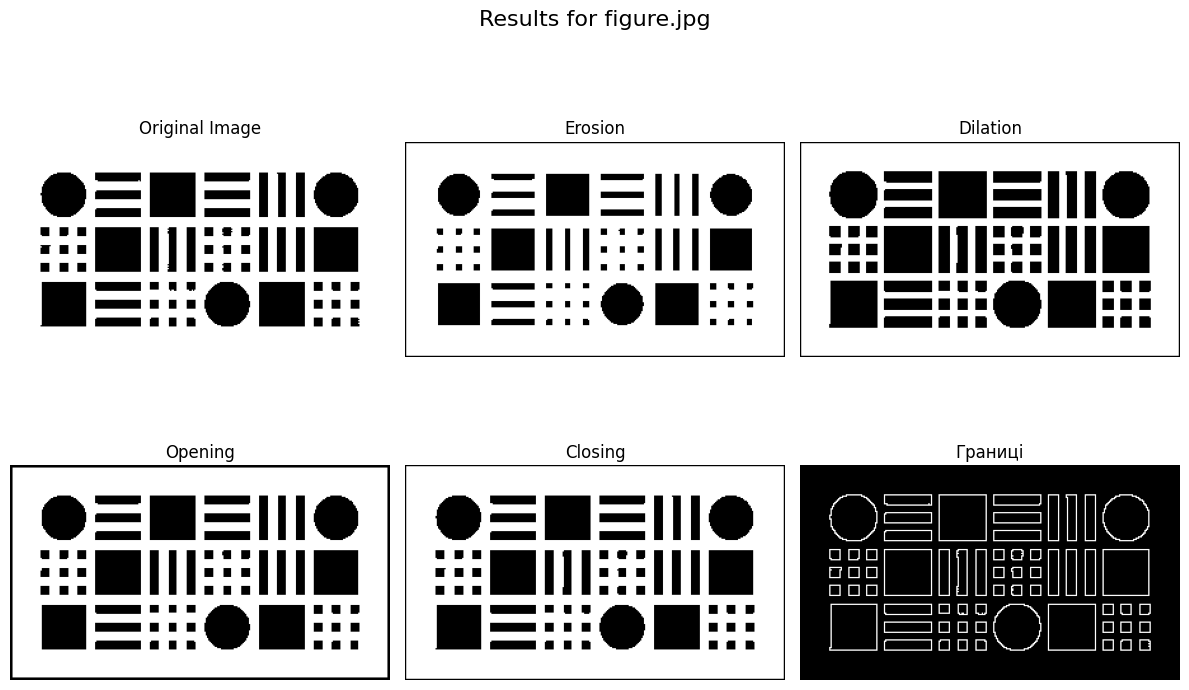

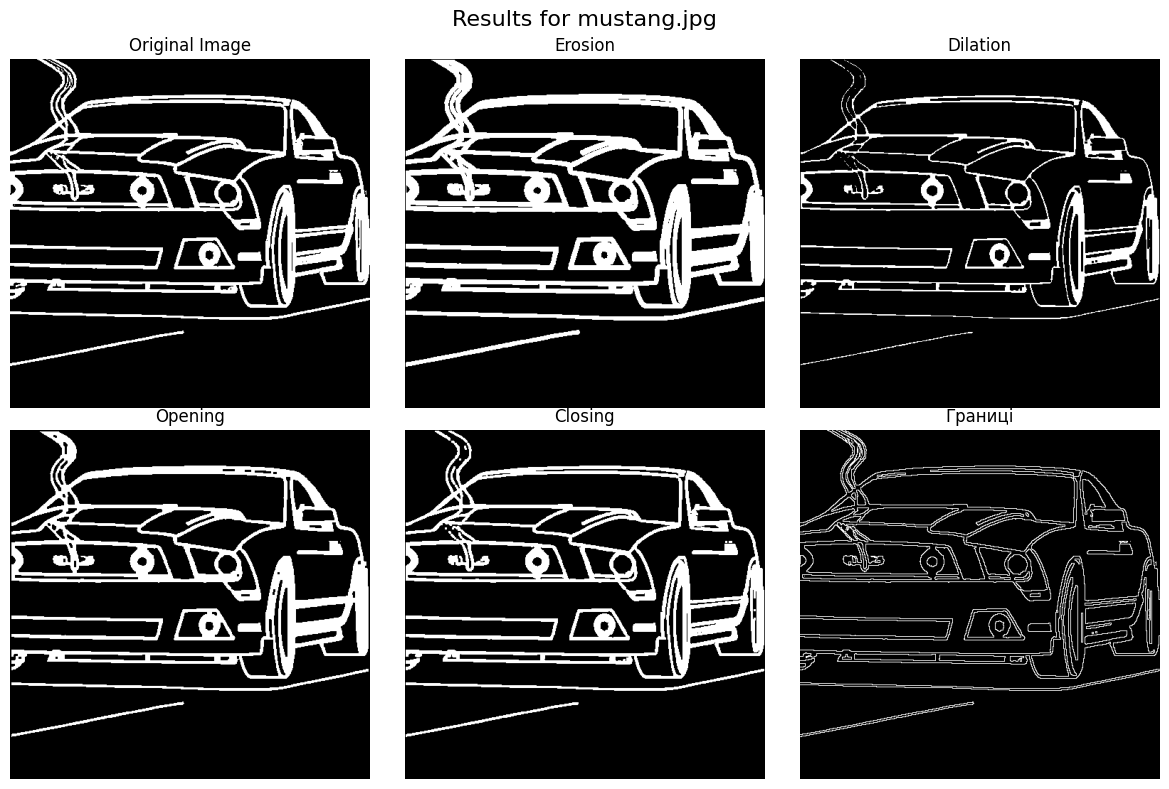

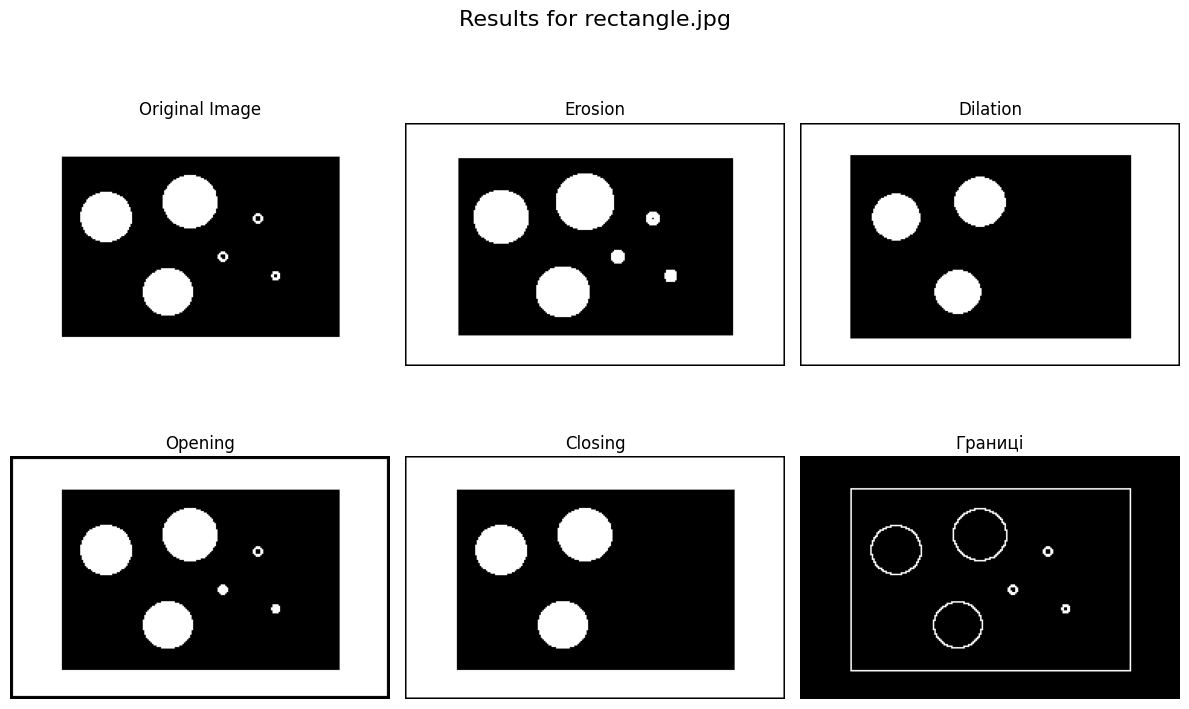

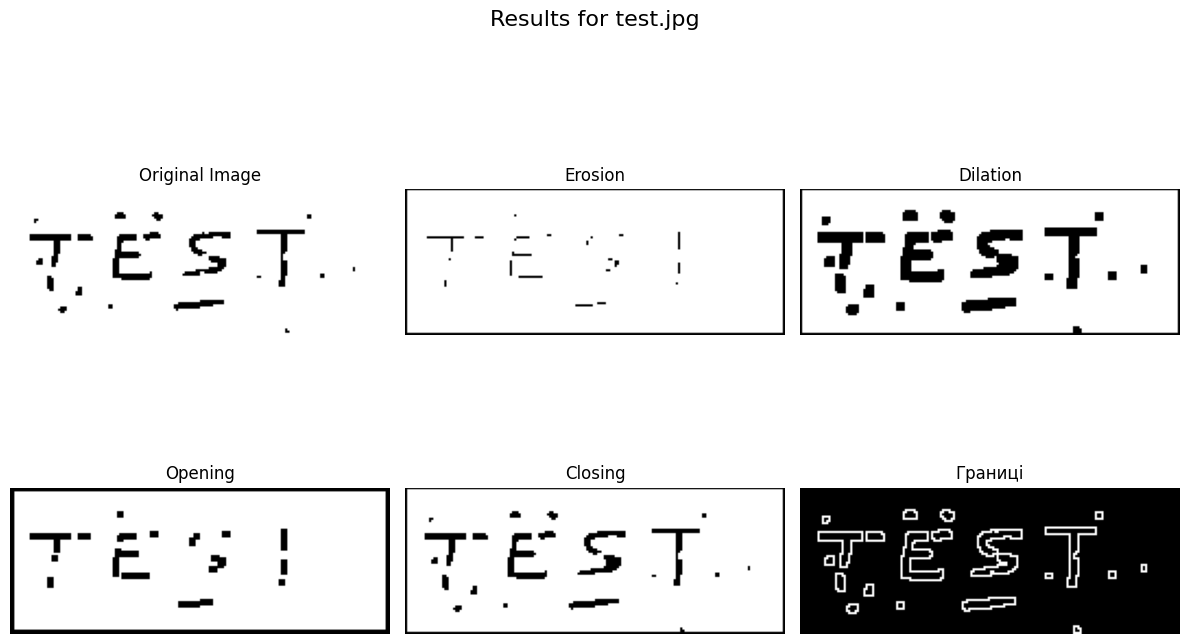

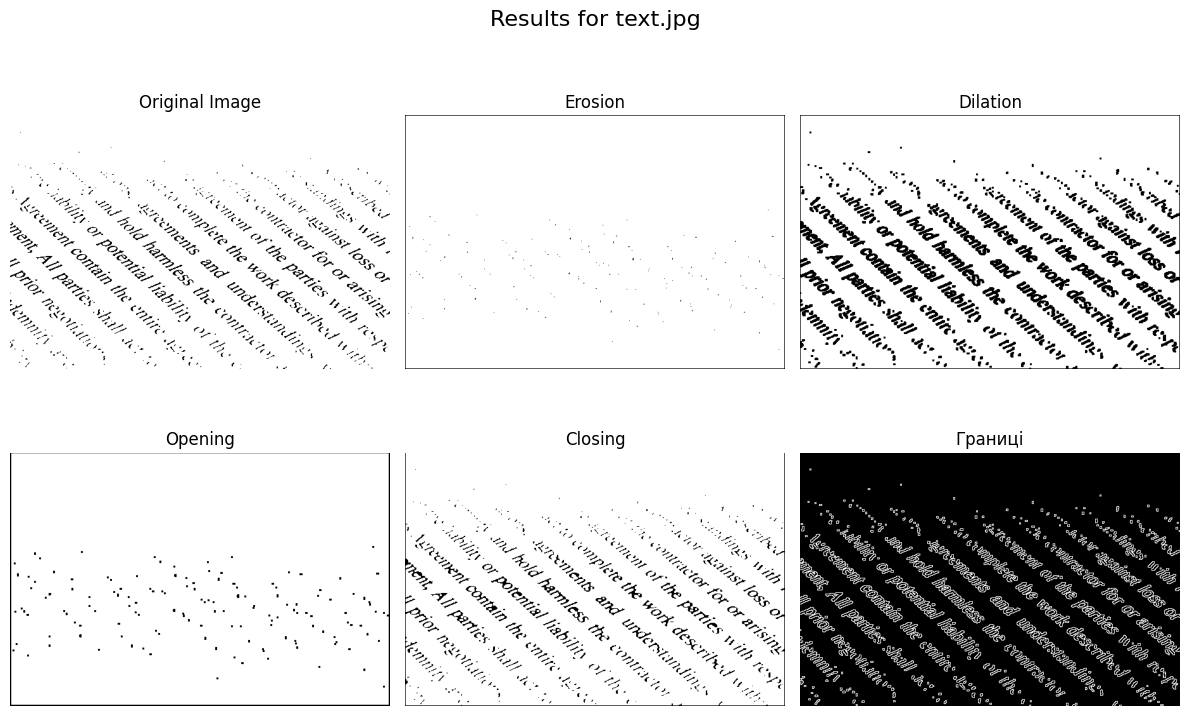

In [9]:
image_files = ["book.jpg", "cat.jpg", "cube.jpg", "figure.jpg", "mustang.jpg", "rectangle.jpg", "test.jpg", "text.jpg"]
kernel_size = 3

for image_path in image_files:
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Cannot load image: {image_path}")
        continue

    _, binary_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

    eroded_image = erosion(binary_image, kernel_size)
    dilated_image = dilation(binary_image, kernel_size)
    opened_image = opening(binary_image, kernel_size)
    closed_image = closing(binary_image, kernel_size)
    boundary_image = border(binary_image, kernel_size)

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(binary_image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(eroded_image, cmap='gray')
    plt.title("Erosion")
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(dilated_image, cmap='gray')
    plt.title("Dilation")
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(opened_image, cmap='gray')
    plt.title("Opening")
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(closed_image, cmap='gray')
    plt.title("Closing")
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(boundary_image, cmap='gray')
    plt.title("Границі")
    plt.axis('off')

    plt.suptitle(f"Results for {image_path}", fontsize=16)
    plt.tight_layout()
    plt.show()